# Ejercicio de Regresión 1 (Core)

Descripción del problema: Supongamos que trabajas en una empresa que desea predecir el precio de venta de casas en función de varias características. Tienes un conjunto de datos con información sobre las casas, incluyendo el tamaño de la casa (en pies cuadrados), el número de habitaciones, el número de baños y la antigüedad de la casa (en años). Tu tarea es construir un modelo de regresión lineal que pueda predecir el precio de venta de una casa dada.

## Carga de datos: 
Descarga el archivo de datos house_prices.csv que contiene las siguientes columnas:
SqFt: Tamaño de la casa en pies cuadrados.
Bedrooms: Número de habitaciones.
Bathrooms: Número de baños.
price: Precio de venta de la casa.

Archivo: https://github.com/ywchiu/riii/blob/master/data/house-prices.csv 



In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/ywchiu/riii/refs/heads/master/data/house-prices.csv')

## Exploración de datos: 
Realiza un análisis exploratorio de los datos para entender su estructura y detectar posibles problemas como valores nulos o outliers.

In [144]:
df

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East
...,...,...,...,...,...,...,...,...
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West


In [145]:
print("======INFO========")
display(df.info())
print("======DESCRIBE========")
display(df.describe())

======INFO========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


None

======DESCRIBE========


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [146]:
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [147]:
df.tail()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West
127,128,124600,2250,3,3,4,No,North


In [148]:
print(f"Cantidad de Duplicados: {df.duplicated().sum()}")
print(f"Cantidad de Nulos: {df.isnull().values.sum()}")


Cantidad de Duplicados: 0
Cantidad de Nulos: 0


In [149]:
#como la columna HOME es un indice, la vamos a eliminar
df.drop(columns=['Home'], inplace=True)

In [150]:
print(f"Valores unicos de Brick: {df['Brick'].value_counts()}")
print(f"Valores unicos de Neighborhood: {df['Neighborhood'].value_counts()}")

Valores unicos de Brick: Brick
No     86
Yes    42
Name: count, dtype: int64
Valores unicos de Neighborhood: Neighborhood
East     45
North    44
West     39
Name: count, dtype: int64


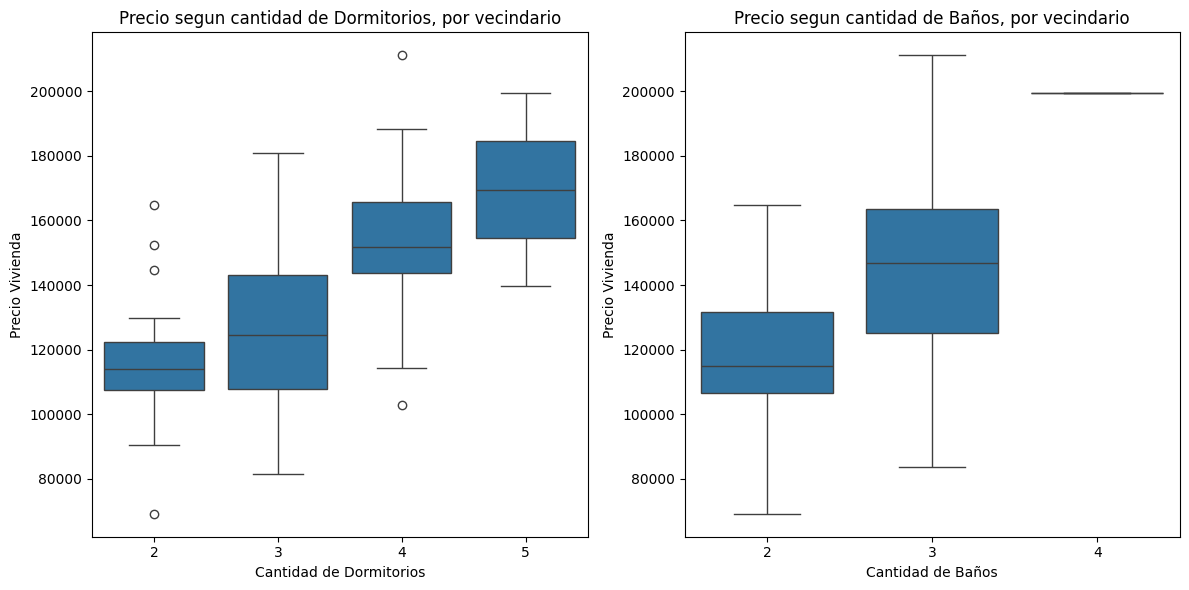

In [151]:
#REVISAMOS PRECIOS SEGUN NUMERO DE DORMITORIOS Y BAÑOS, PARA REVISAR OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='Bedrooms', y='Price', data=df, ax=axes[0])
axes[0].set_title('Precio segun cantidad de Dormitorios, por vecindario')
axes[0].set_xlabel('Cantidad de Dormitorios')
axes[0].set_ylabel('Precio Vivienda')

sns.boxplot(x='Bathrooms', y='Price', data=df, ax=axes[1])
axes[1].set_title('Precio segun cantidad de Baños, por vecindario')
axes[1].set_xlabel('Cantidad de Baños')
axes[1].set_ylabel('Precio Vivienda')

plt.tight_layout()
plt.show()

In [152]:
display(df['Bedrooms'].value_counts())
display(df['Bathrooms'].value_counts())


df.query('Bedrooms == 5')

Bedrooms
3    67
2    30
4    29
5     2
Name: count, dtype: int64

Bathrooms
2    72
3    55
4     1
Name: count, dtype: int64

,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
33,139600,2280,5,3,4,Yes,East
116,199500,2290,5,4,1,Yes,West


---
* Solo existe 2 casas con 5 habitaciones
* Solo existe 1 casa con 4 baños (que tambien tiene 5 habitaciones)
* Las casas de 2 habitaciones presentan alta variacion en sus precios, con muchos outliers
---

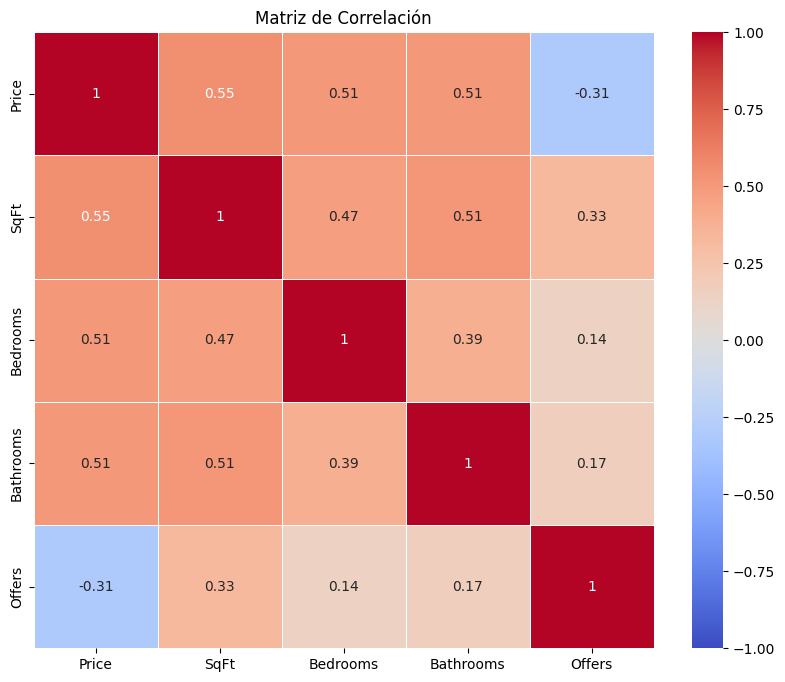

In [153]:
#REVISAMOS CORRELACION ENTRE VARIABLES NUMERICAS
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(method='spearman', numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

---
* No se observan correlaciones fuertes solo con las columnas numericas
* Como habian outliers en la relacion cantidad de habitaciones/precio, se utilizo el metodo de spearman para hacer la correlacion, aunque hubo cambios menores en valores y las proporciones se mantuvieron inalteradas al compararlos con el metodo estandar (pearson)
* Vemos que Price se correlaciona de manera similar a Tamaño de la Casa, su cantidad de habitaciones y su cantidad de baños
* Vamos a realizar el modelo de regresion como fue enseñado inicialmente
* despues se realizara nuevamente, pero esta vez agregando encoding
---


## Preparación de datos: 
Divide los datos en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%).


In [154]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Separar features y target
X = df[['SqFt', 'Bedrooms', 'Bathrooms']]
y = df['Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizamos
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)


## Entrenamiento del modelo: 
Entrena un modelo de regresión lineal utilizando los datos de entrenamiento.

In [155]:
modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)

y_pred = modelo.predict(X_test_esc)

## Evaluación del modelo: 
Evalúa el modelo utilizando el conjunto de prueba. Calcula el error cuadrático medio (MSE) y el R-cuadrado (R²) del modelo.

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MAE:   {mae:>12,.0f}    (error promedio en dólares)')
print(f'MSE:   {mse:>12,.0f}    (en dólares cuadrados)')
print(f'RMSE:  {rmse:>12,.0f}    (en dólares)')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')

📊 Evaluación del modelo
──────────────────────────────────────────────────
MAE:         14,768    (error promedio en dólares)
MSE:    320,149,938    (en dólares cuadrados)
RMSE:        17,893    (en dólares)
R²:          0.4568    (45.7% de la varianza explicada)


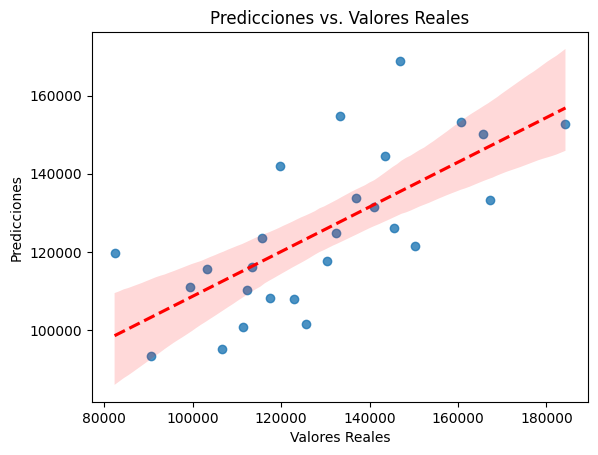

In [ ]:
#GRAFICO LA RELACION ENTRE VALORES REALES Y PREDICCIONES CON LINEA DE TENDENCIA
#SOLO COMO UNA AYUDA VISUAL DEL MODELO, PORQUE ME HUBIESE GUSTADO UN R-CUADRADO MAYOR
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red', 'linestyle': '--'})
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales')
plt.show()

## Predicción: 
Usa el modelo entrenado para predecir el precio de una casa con las siguientes características:
Tamaño: 2000 pies cuadrados
Habitaciones: 3
Baños: 2

In [158]:
#Se crea diccionario con la casa a evaluar
CasaEvaluar = {
    'SqFt': [2000],
    'Bedrooms': [3],
    'Bathrooms': [2]
}

#convertimos a dataframe
EvalHouse = pd.DataFrame(CasaEvaluar)

#escalamos los valores de acuerdo al paso de estandarizacion
EvalHouse_esc = scaler.transform(EvalHouse)

#aplicamos el modelo a la casa a evaluar
PrecioPred = modelo.predict(EvalHouse_esc)

# se muestra el valor predicho
print(f'Precio Predicho: ${PrecioPred[0]:,.0f}')


Precio Predicho: $123,537


## Extra: Usando Encoding para obtener un mejor modelo

In [159]:
from sklearn.preprocessing import OneHotEncoder

# VAMOS A INCORPORAR BRICK Y NEIGHBOURHOOD AL MODELO
ohe = OneHotEncoder(sparse_output=False, drop='first')
matriz = ohe.fit_transform(df[['Brick', 'Neighborhood']])

In [160]:
# CREAMOS EL DATAFRAME CODIFICADO
df_codificado = pd.DataFrame(matriz, columns=ohe.get_feature_names_out(['Brick', 'Neighborhood']))

#AGREGAMOS LAS COLUMNAS CODIFICADAS Y ELIMINAMOS LAS COLUMNAS ORIGINALES
df_unido = pd.concat([df, df_codificado], axis=1)
df_unido.drop(columns=['Brick', 'Neighborhood'], inplace=True)

#df_unido fue revisando antes de hacer el drop de columnas para asegurar que el enconding fuera congruente

In [161]:
#HACEMOS EL MODELO DE REGRESION CON TODOS LOS FACTORES
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Separar features y target
X = df_unido.drop(columns=['Price'])
y = df_unido['Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizamos
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)

y_pred = modelo.predict(X_test_esc)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('📊 Evaluación del modelo')
print('─' * 50)
print(f'MAE:   {mae:>12,.0f}    (error promedio en dólares)')
print(f'MSE:   {mse:>12,.0f}    (en dólares cuadrados)')
print(f'RMSE:  {rmse:>12,.0f}    (en dólares)')
print(f'R²:    {r2:>12.4f}    ({r2*100:.1f}% de la varianza explicada)')

📊 Evaluación del modelo
──────────────────────────────────────────────────
MAE:          8,901    (error promedio en dólares)
MSE:    114,170,418    (en dólares cuadrados)
RMSE:        10,685    (en dólares)
R²:          0.8063    (80.6% de la varianza explicada)


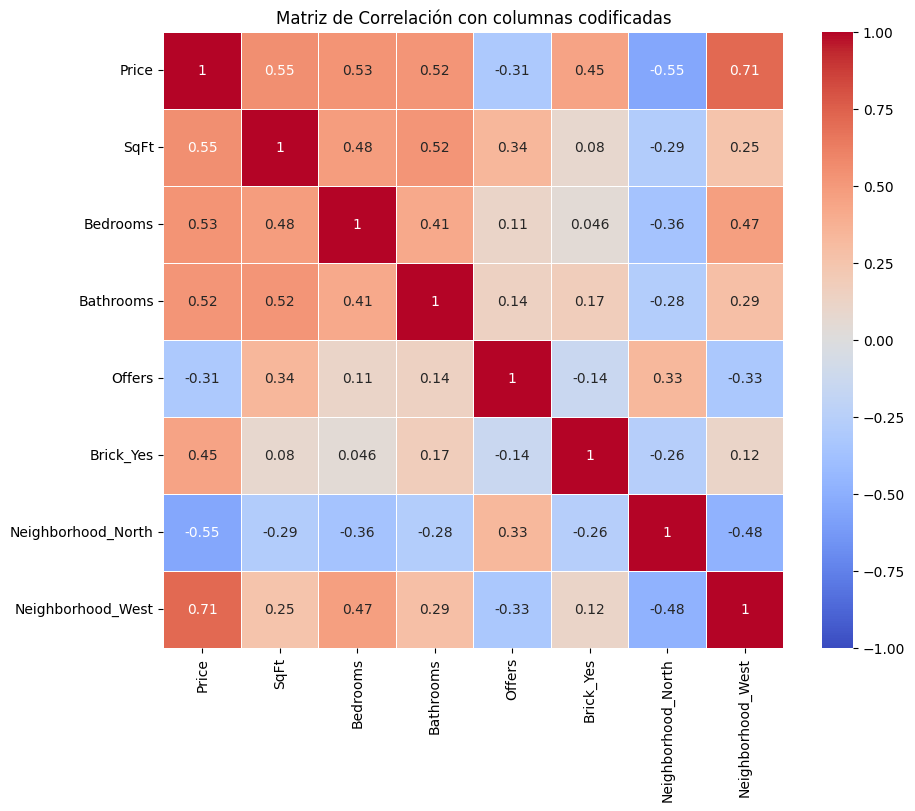

In [162]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_unido.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación con columnas codificadas')
plt.show()

---
* El modelo pasa de un R-cuadrado de 0.46 a 0.81 al incorporar si la casa es de ladrillo y el vecindario
* Ahi se observa que existe una correlacion positiva en el precio cuando el vecindario es West, y una correlacion negativa cuando el vecindario es North
---

In [163]:
#VAMOS A PREDECIR EL PRECIO DE LA MISMA CASA, EN EL BARRIO NORTH
CasaEvaluar = {
    'SqFt': [2000],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'Offers' : [1],
    'Brick_Yes' : [0],
    'Neighborhood_North': [1],
    'Neighborhood_West': [0]
}

#convertimos a dataframe
EvalHouse = pd.DataFrame(CasaEvaluar)

#escalamos los valores de acuerdo al paso de estandarizacion
EvalHouse_esc = scaler.transform(EvalHouse)

#aplicamos el modelo a la casa a evaluar
PrecioPred = modelo.predict(EvalHouse_esc)

# se muestra el valor predicho
print(f'Precio Predicho: ${PrecioPred[0]:,.0f}')

Precio Predicho: $129,585


In [164]:
#VAMOS A PREDECIR EL PRECIO DE LA MISMA CASA, EN BARRIO WEST
CasaEvaluar = {
    'SqFt': [2000],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'Offers' : [1],
    'Brick_Yes' : [0],
    'Neighborhood_North': [0],
    'Neighborhood_West': [1]
}

#convertimos a dataframe
EvalHouse = pd.DataFrame(CasaEvaluar)

#escalamos los valores de acuerdo al paso de estandarizacion
EvalHouse_esc = scaler.transform(EvalHouse)

#aplicamos el modelo a la casa a evaluar
PrecioPred = modelo.predict(EvalHouse_esc)

# se muestra el valor predicho
print(f'Precio Predicho: ${PrecioPred[0]:,.0f}')

Precio Predicho: $150,203
